# Raw Crude Oil Futures Data Exploration

This notebook documents the first inspection of the raw Databento data before cleaning.

The source file is a Databento Binary Encoding (`.dbn`) file downloaded from `GLBX.MDP3` using the `CL.FUT` parent symbol. It contains daily OHLCV records for crude-oil futures and related instruments. The raw file is kept unchanged; filtering and rollover preparation belong in `src/prepare_data.py`.

In [2]:
from pathlib import Path

import databento as db
import pandas as pd


candidates = [
    Path("data/raw/crude_oil_all_daily.dbn"),
    Path("../data/raw/crude_oil_all_daily.dbn"),
]
raw_path = next(path for path in candidates if path.exists())
raw_store = db.DBNStore.from_file(raw_path)
raw = raw_store.to_df()
raw.index.name = "ts_event"

print(f"Loaded {raw_path}")
print(f"Rows: {len(raw):,}")
raw.head()

Loaded ../data/raw/crude_oil_all_daily.dbn
Rows: 777,383


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2010-06-06 00:00:00+00:00,35,1,182020,79.86,79.86,79.58,79.70,55,CLZ1
2010-06-06 00:00:00+00:00,35,1,182055,70.35,70.59,70.16,70.34,3489,CLN0
2010-06-06 00:00:00+00:00,35,1,182062,77.20,77.22,77.20,77.22,2,CLH1
2010-06-06 00:00:00+00:00,35,1,182057,73.32,73.32,72.46,72.68,102,CLU0
2010-06-06 00:00:00+00:00,35,1,182010,75.39,75.44,75.11,75.20,96,CLZ0


## Dataset coverage and schema

The raw file contains daily OHLCV records. `instrument_id` is retained because a displayed raw symbol can be reused for different contract lifecycles.

In [3]:
coverage = pd.Series(
    {
        "rows": len(raw),
        "columns": len(raw.columns),
        "unique_symbols": raw["symbol"].nunique(),
        "unique_instrument_ids": raw["instrument_id"].nunique(),
        "first_timestamp": raw.index.min(),
        "last_timestamp": raw.index.max(),
    }
)
coverage

rows                                        777383
columns                                          9
unique_symbols                                3624
unique_instrument_ids                         5140
first_timestamp          2010-06-06 00:00:00+00:00
last_timestamp           2026-10-07 00:00:00+00:00
dtype: object

## Raw-data quality checks

These checks describe the file before any filtering or imputation. A zero count here does not prove the data is economically complete; it only describes the records returned by Databento.

In [5]:
ohlcv_columns = ["open", "high", "low", "close", "volume"]
quality = pd.Series(
    {
        "missing_ohlcv_values": int(raw[ohlcv_columns].isna().sum().sum()),
        "missing_symbols": int(raw["symbol"].isna().sum()),
        "duplicate_timestamp_symbol_rows": int(
            raw.reset_index().duplicated(subset=["ts_event", "symbol"]).sum()
        ),
        "zero_volume_rows": int((raw["volume"] == 0).sum()),
        "negative_close_rows": int((raw["close"] < 0).sum()),
        "minimum_low": raw["low"].min(),
        "maximum_high": raw["high"].max(),
    }
)
quality

missing_ohlcv_values                    0.0
missing_symbols                         0.0
duplicate_timestamp_symbol_rows         0.0
zero_volume_rows                        0.0
negative_close_rows                244390.0
minimum_low                           -62.3
maximum_high                          130.5
dtype: float64

## Instrument mix

The parent-level query includes outright contracts and related instruments. The regular-expression filter below is only an exploratory label; final filtering should use Databento instrument metadata and preserve `instrument_id`.

In [6]:
raw["instrument_class"] = "other"
raw.loc[raw["symbol"].str.match(r"^CL[A-Z][0-9]+$"), "instrument_class"] = "outright_candidate"
raw.loc[raw["symbol"].str.contains("-", regex=False), "instrument_class"] = "spread_candidate"

instrument_mix = raw.groupby("instrument_class").agg(
    rows=("instrument_id", "size"),
    symbols=("symbol", "nunique"),
    instruments=("instrument_id", "nunique"),
)
instrument_mix

,rows,symbols,instruments
instrument_class,,,
other,16,10,10
outright_candidate,109962,136,248
spread_candidate,667405,3478,4883


- outright_candidates --> symbol looks like a direct crude-oil futures contract (such as CLZ4, CLH5, and CLM6)
- spread_candidates --> symbol that contains hypen (such as CLZ2-CLM3 and CLF2-CLG2)

columns:
- rows --> number of daily market-data records
- symbols --> number of unique displayed symbols (such as CLZ4)
- instruments --> number of unique underlying Databento instruments

since there is more instruments than symbol, `instrument_id` is a safer identifier for cleaning, contract history, and rollover logic.

## Contract identity and outright checks

A raw symbol can be reused across different contract lifecycles. The example below shows why `instrument_id` must remain part of the cleaned contract key.

In [8]:
outright = raw[raw["instrument_class"].eq("outright_candidate")].copy()

symbol_reuse = (
    outright.groupby("symbol")["instrument_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .rename("instrument_ids")
)

outright_quality = pd.Series(
    {
        "rows": len(outright),
        "symbols": outright["symbol"].nunique(),
        "instrument_ids": outright["instrument_id"].nunique(),
        "negative_close_rows": int((outright["close"] < 0).sum()),
        "zero_volume_rows": int((outright["volume"] == 0).sum()),
    }
)

print("Outright candidate summary")
display(outright_quality)
print("\nSymbols with the most instrument IDs")
display(symbol_reuse)

example_symbol = "CLZ9"
example_reuse = (
    outright[outright["symbol"].eq(example_symbol)]
    .reset_index()
    .groupby("instrument_id")
    .agg(first_date=("ts_event", "min"), last_date=("ts_event", "max"), rows=("ts_event", "size"))
)
print(f"{example_symbol} instrument history")
display(example_reuse)

Outright candidate summary


rows                   109962
symbols                   136
instrument_ids            248
negative_close_rows         1
zero_volume_rows            0
dtype: int64


Symbols with the most instrument IDs


symbol
CLN3    2
CLU7    2
CLU5    2
CLU4    2
CLU3    2
CLU2    2
CLU1    2
CLU0    2
CLQ9    2
CLQ8    2
Name: instrument_ids, dtype: int64

CLZ9 instrument history


,first_date,last_date,rows
instrument_id,,,
327892,2010-12-06 00:00:00+00:00,2019-11-20 00:00:00+00:00,1913
436191,2020-02-19 00:00:00+00:00,2026-10-07 00:00:00+00:00,493


In /Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'
In /Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'
In /Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /Users/winonawiem/opt/anaconda3/envs/futures-project/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/

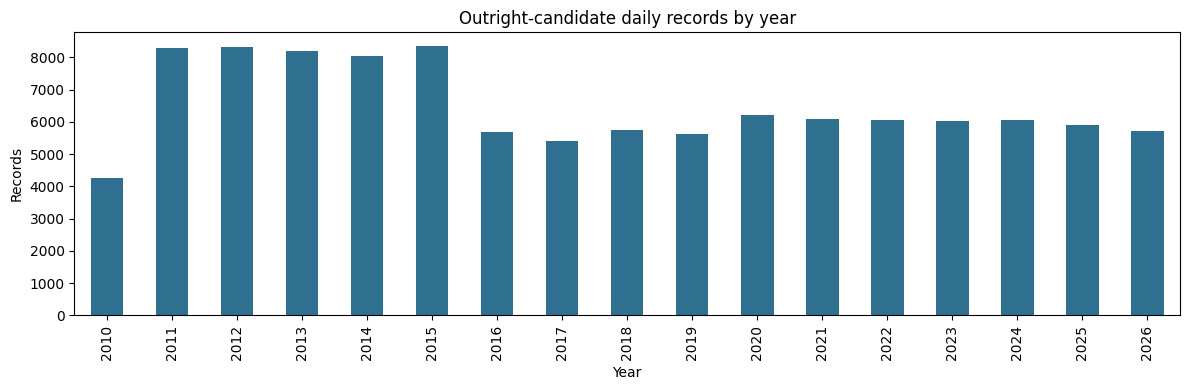

In [9]:
import matplotlib.pyplot as plt

annual_rows = outright.resample("YE").size()
annual_rows.index = annual_rows.index.year

ax = annual_rows.plot(kind="bar", figsize=(12, 4), color="#2f6f8f")
ax.set_title("Outright-candidate daily records by year")
ax.set_xlabel("Year")
ax.set_ylabel("Records")
plt.tight_layout()
plt.show()

## Findings before cleaning

- The raw file contains 777,383 daily records from June 6, 2010 through October 7, 2026.
- The file has no missing OHLCV values, missing symbols, duplicate timestamp/symbol rows, or zero-volume rows.
- The parent-level query includes many calendar spreads and related instruments, not only outright crude-oil contracts.
- The exploratory outright pattern identifies 109,962 rows across 136 displayed symbols and 248 instrument IDs.
- Negative closes are common in the full raw file because spread values can be negative. The outright candidate subset contains one negative close, which should be investigated separately rather than automatically removed.
- Raw symbols are reused across contract lifecycles. Contract identity must therefore use `instrument_id` together with the displayed symbol and timestamp.
- Databento reported some historical dates with reduced quality during download; those dates need to be documented and reviewed during preparation.

The next cleaning step should use instrument metadata to distinguish outright contracts from spreads, preserve `instrument_id`, validate contract date ranges, and save a processed dataset separately from the raw DBN file.

## Choosing an intraday time range

The intraday sample should be long enough to include different market regimes, but narrow enough to keep the download and cleaning process manageable. Use the daily data first to identify periods with good outright-contract coverage, then choose a common start and end date for the intraday query. The coverage table and contract plots below show where each instrument has observations.

The full daily file contains many contracts with different lifetimes, so the maximum overlap across every contract is not a useful target. A practical first intraday window should instead cover a continuous sequence of tradable contracts and include the development and holdout periods agreed in the project scope.

Outright instruments: 248


,,first_date,last_date,daily_rows
instrument_id,symbol,,,
182062,CLH1,2010-06-06 00:00:00+00:00,2011-02-22 00:00:00+00:00,211
182059,CLX0,2010-06-06 00:00:00+00:00,2010-10-20 00:00:00+00:00,118
182058,CLV0,2010-06-06 00:00:00+00:00,2010-09-21 00:00:00+00:00,93
182057,CLU0,2010-06-06 00:00:00+00:00,2010-08-20 00:00:00+00:00,66
182056,CLQ0,2010-06-06 00:00:00+00:00,2010-07-20 00:00:00+00:00,39
182020,CLZ1,2010-06-06 00:00:00+00:00,2011-11-18 00:00:00+00:00,438
182055,CLN0,2010-06-06 00:00:00+00:00,2010-06-22 00:00:00+00:00,15
182065,CLM1,2010-06-06 00:00:00+00:00,2011-05-20 00:00:00+00:00,277
182010,CLZ0,2010-06-06 00:00:00+00:00,2010-11-19 00:00:00+00:00,144


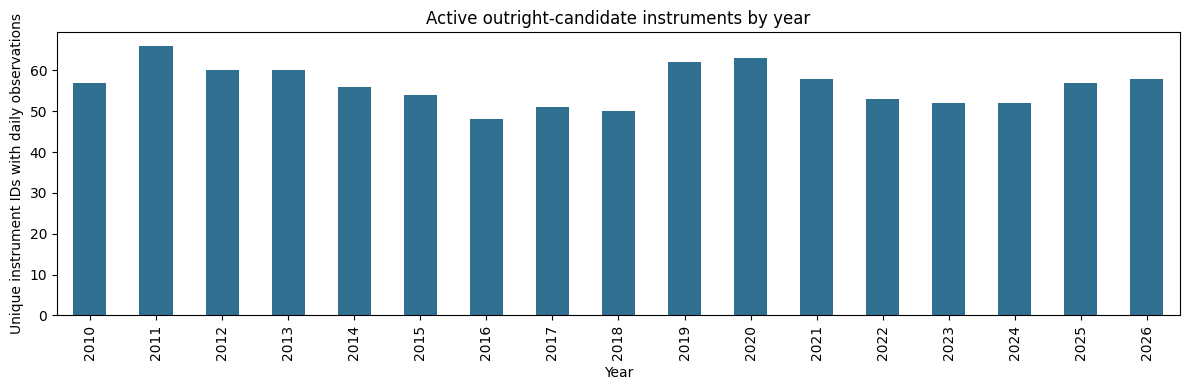

In [13]:
from pathlib import Path

if "outright" not in globals():
    import databento as db

    data_candidates = [
        Path("data/raw/crude_oil_all_daily.dbn"),
        Path("../data/raw/crude_oil_all_daily.dbn"),
    ]
    raw_path_for_coverage = next(path for path in data_candidates if path.exists())
    raw_for_coverage = db.DBNStore.from_file(raw_path_for_coverage).to_df()
    outright = raw_for_coverage[raw_for_coverage["symbol"].str.match(r"^CL[A-Z][0-9]+$")].copy()

contract_coverage = (
    outright.reset_index()
    .groupby(["instrument_id", "symbol"])
    .agg(
        first_date=("ts_event", "min"),
        last_date=("ts_event", "max"),
        daily_rows=("ts_event", "size"),
    )
    .sort_values("first_date")
)

print(f"Outright instruments: {len(contract_coverage):,}")
display(contract_coverage.head(20))

coverage_by_year = (
    outright.assign(year=outright.index.year)
    .groupby("year")["instrument_id"]
    .nunique()
)

ax = coverage_by_year.plot(kind="bar", figsize=(12, 4), color="#2f6f8f")
ax.set_title("Active outright-candidate instruments by year")
ax.set_xlabel("Year")
ax.set_ylabel("Unique instrument IDs with daily observations")
plt.tight_layout()
plt.show()

## Daily close plots for each instrument

A single chart with all contracts would be difficult to read. The following cell creates a multi-page PDF with 12 panels per page. Each panel is labeled with the displayed symbol and the unique `instrument_id`, so reused symbols remain distinguishable.

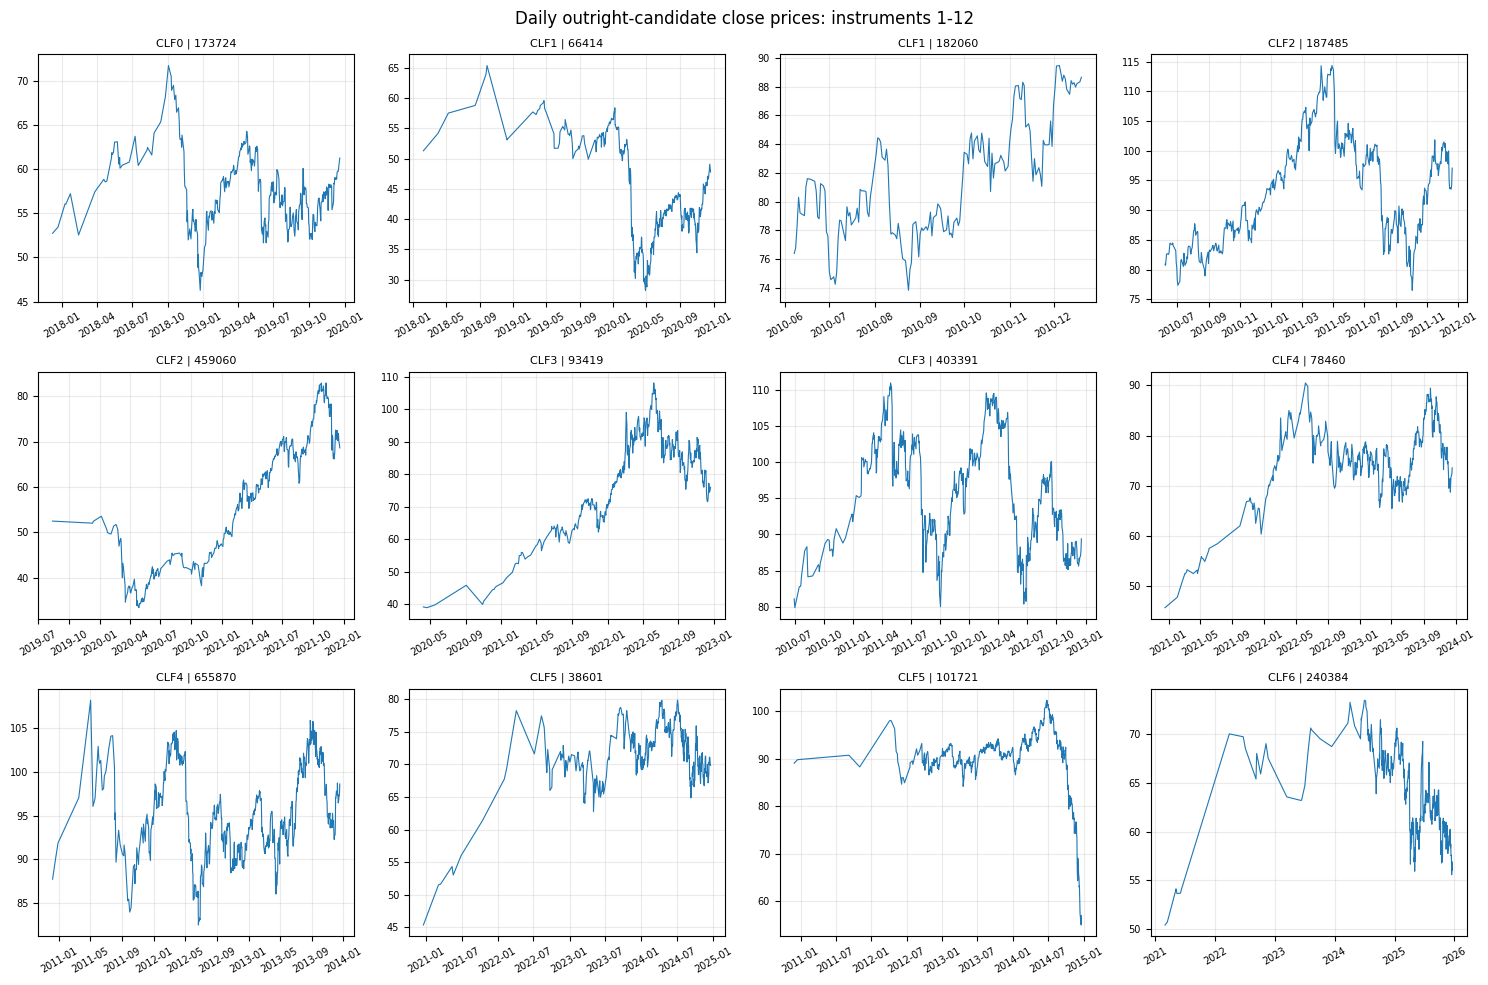

Saved 248 instrument plots to ../reports/figures/outright_daily_close_by_instrument.pdf
First page preview saved to ../reports/figures/outright_daily_close_by_instrument_page_01.png


In [12]:
from pathlib import Path

import databento as db
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

if "outright" not in globals():
    data_candidates = [
        Path("data/raw/crude_oil_all_daily.dbn"),
        Path("../data/raw/crude_oil_all_daily.dbn"),
    ]
    raw_path_for_plot = next(path for path in data_candidates if path.exists())
    raw_for_plot = db.DBNStore.from_file(raw_path_for_plot).to_df()
    outright = raw_for_plot[raw_for_plot["symbol"].str.match(r"^CL[A-Z][0-9]+$")].copy()

figures_candidates = [Path("reports/figures"), Path("../reports/figures")]
figures_dir = next((path for path in figures_candidates if path.exists()), figures_candidates[-1])
figures_dir.mkdir(parents=True, exist_ok=True)
prices_pdf = figures_dir / "outright_daily_close_by_instrument.pdf"

contract_keys = (
    outright.reset_index()[["instrument_id", "symbol"]]
    .drop_duplicates()
    .sort_values(["symbol", "instrument_id"])
)
page_size = 12
first_page = None

with PdfPages(prices_pdf) as pdf:
    for page_start in range(0, len(contract_keys), page_size):
        page_keys = contract_keys.iloc[page_start : page_start + page_size]
        fig, axes = plt.subplots(3, 4, figsize=(15, 10), squeeze=False)
        axes = axes.ravel()

        for axis, (_, key) in zip(axes, page_keys.iterrows()):
            instrument_data = outright[
                (outright["instrument_id"] == key["instrument_id"])
                & (outright["symbol"] == key["symbol"])
            ]
            axis.plot(instrument_data.index, instrument_data["close"], linewidth=0.8)
            axis.set_title(f"{key['symbol']} | {key['instrument_id']}", fontsize=8)
            axis.tick_params(axis="x", labelrotation=30, labelsize=7)
            axis.tick_params(axis="y", labelsize=7)
            axis.grid(alpha=0.25)

        for axis in axes[len(page_keys) :]:
            axis.set_visible(False)

        fig.suptitle(
            f"Daily outright-candidate close prices: instruments {page_start + 1}-{page_start + len(page_keys)}",
            fontsize=12,
        )
        fig.tight_layout()
        pdf.savefig(fig)
        if first_page is None:
            first_page = fig
        else:
            plt.close(fig)

if first_page is not None:
    first_page_path = figures_dir / "outright_daily_close_by_instrument_page_01.png"
    first_page.savefig(first_page_path, dpi=150)
    plt.show()
    plt.close(first_page)

print(f"Saved {len(contract_keys):,} instrument plots to {prices_pdf}")
print(f"First page preview saved to {first_page_path}")

## Overlay of daily close paths

This alternative view overlays each outright-candidate instrument on the same axes. The horizontal axis is closing price and the vertical axis is date. Each line is labeled at its final observation with the displayed symbol and `instrument_id`.

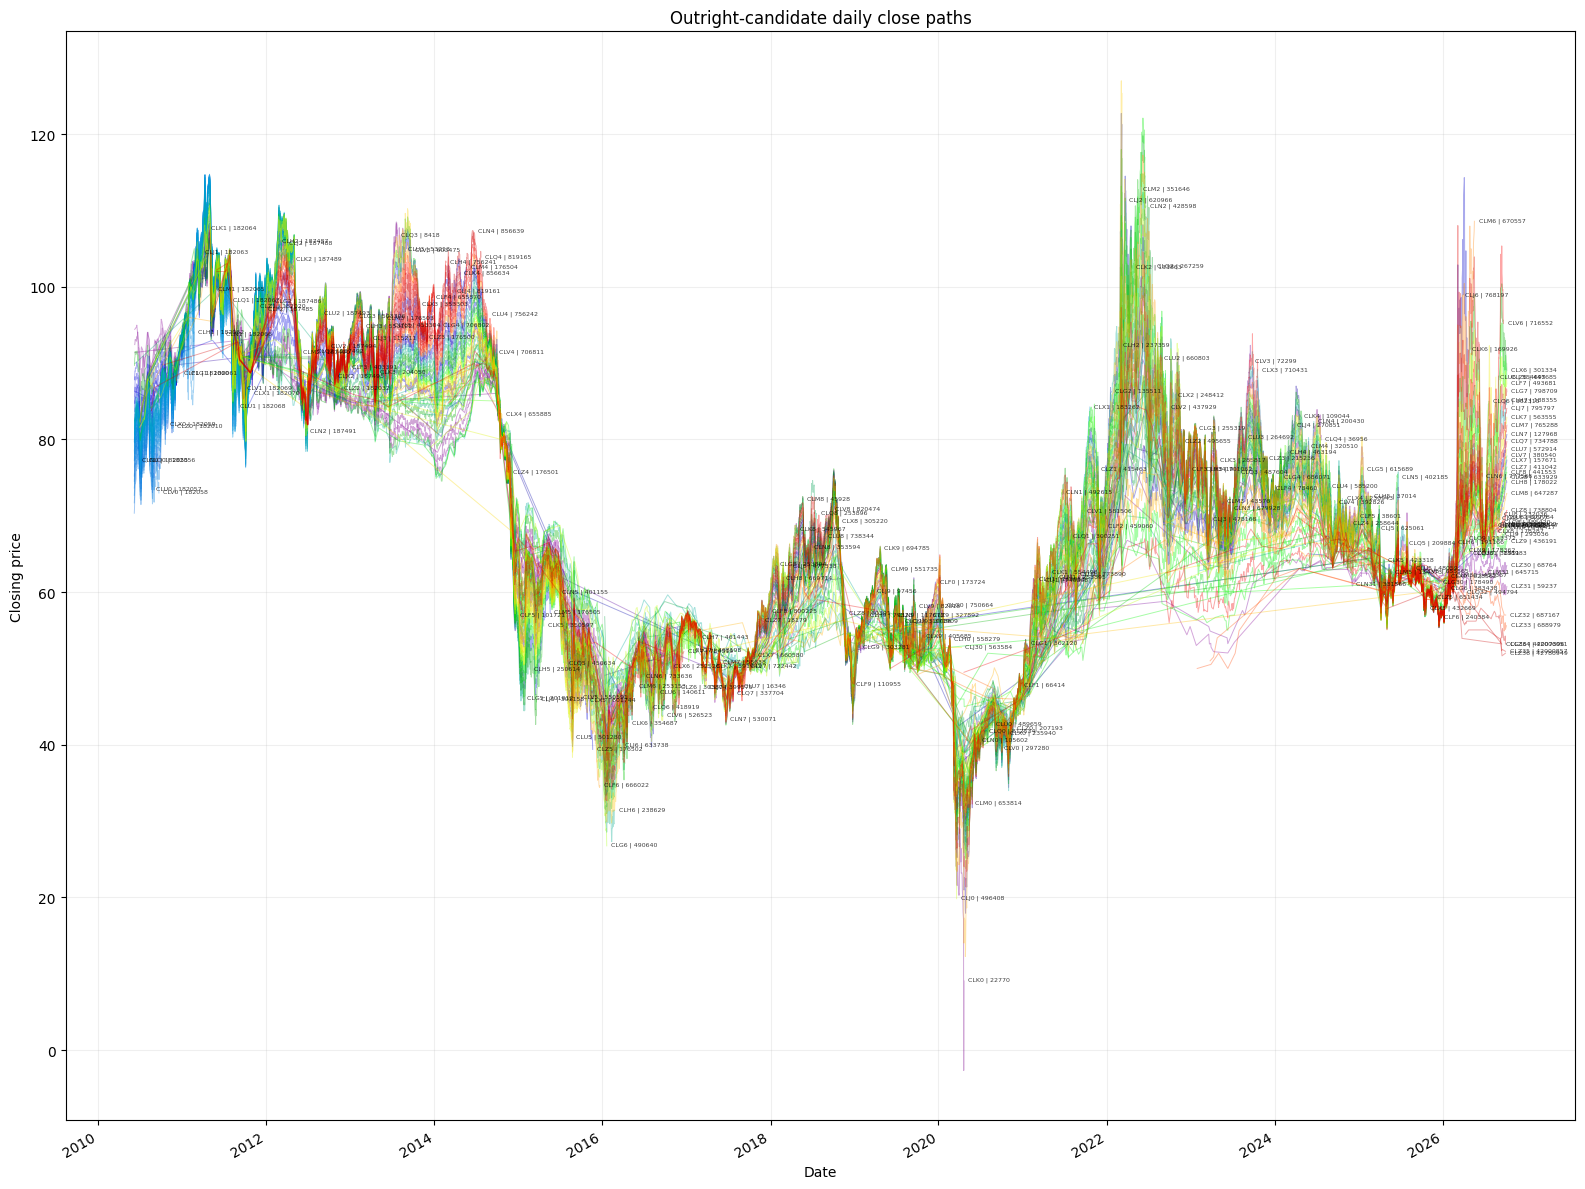

Saved overlay PDF to ../reports/figures/outright_daily_close_date_overlay.pdf
Saved overlay PNG to ../reports/figures/outright_daily_close_date_overlay.png


In [16]:
import numpy as np

from matplotlib.backends.backend_pdf import PdfPages

overlay_pdf = figures_dir / "outright_daily_close_date_overlay.pdf"
overlay_png = figures_dir / "outright_daily_close_date_overlay.png"

fig, ax = plt.subplots(figsize=(16, 12))
colors = plt.cm.nipy_spectral(
    np.linspace(0.05, 0.95, outright["instrument_id"].nunique())
)

for color, ((instrument_id, symbol), instrument_data) in zip(
    colors,
    outright.reset_index().groupby(["instrument_id", "symbol"], sort=True),
):
    instrument_data = instrument_data.sort_values("ts_event")
    ax.plot(
        instrument_data["ts_event"],
        instrument_data["close"],
        color=color,
        linewidth=0.7,
        alpha=0.35,
    )
    final_point = instrument_data.iloc[-1]
    ax.annotate(
        f"{symbol} | {instrument_id}",
        (final_point["ts_event"], final_point["close"]),
        xytext=(3, 0),
        textcoords="offset points",
        fontsize=4.5,
        alpha=0.75,
    )

ax.set_title("Outright-candidate daily close paths")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price")
ax.grid(alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(overlay_pdf)
fig.savefig(overlay_png, dpi=180)
plt.show()
plt.close(fig)

print(f"Saved overlay PDF to {overlay_pdf}")
print(f"Saved overlay PNG to {overlay_png}")